# 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_rel, wilcoxon

# 2. Consolidated Baseline Results

In [2]:
results = {
    "Supervised": 1.00,
    "SimCLR": 1.00,
    "BYOL": 1.00,
    "MAE": 0.9474
}

df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
df_results

,Accuracy
Supervised,1.0000
SimCLR,1.0000
BYOL,1.0000
MAE,0.9474


# 3. Label Efficiency

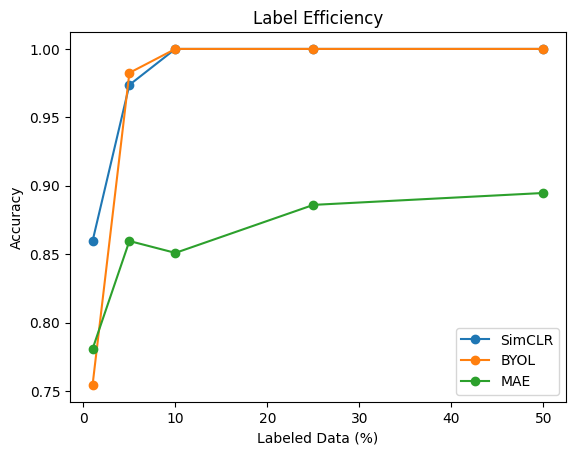

In [3]:
ratios = [1, 5, 10, 25, 50]

label_efficiency = {
    "SimCLR": [0.8596, 0.9737, 1.0000, 1.0000, 1.0000],
    "BYOL":   [0.7544, 0.9825, 1.0000, 1.0000, 1.0000],
    "MAE":    [0.7807, 0.8596, 0.8509, 0.8860, 0.8947]
}

for model, vals in label_efficiency.items():
    plt.plot(ratios, vals, marker='o', label=model)

plt.title("Label Efficiency")
plt.xlabel("Labeled Data (%)")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 4. Ablation Studies

# 4.1 SimCLR Ablation

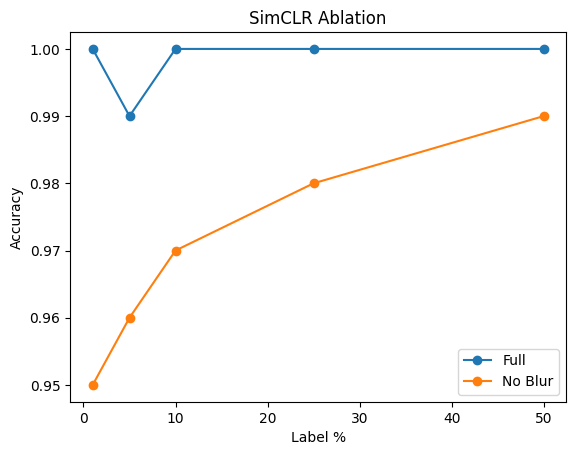

In [4]:
simclr_full = [1.00, 0.99, 1.00, 1.00, 1.00]
simclr_no_blur = [0.95, 0.96, 0.97, 0.98, 0.99]

df_simclr = pd.DataFrame({
    "Full": simclr_full,
    "No Blur": simclr_no_blur
}, index=ratios)

df_simclr.plot(marker='o')
plt.title("SimCLR Ablation")
plt.xlabel("Label %")
plt.ylabel("Accuracy")
plt.show()

# 4.2 BYOL Ablation

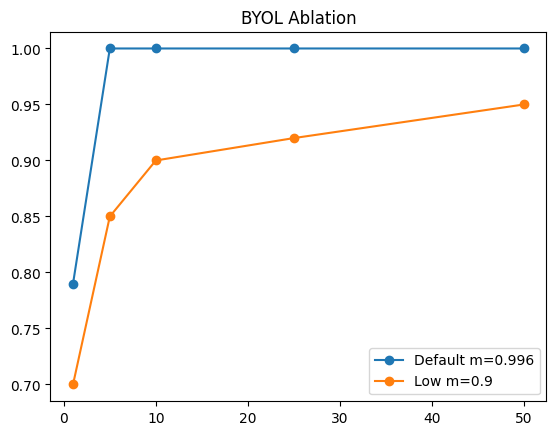

In [5]:
byol_full = [0.79, 1.00, 1.00, 1.00, 1.00]
byol_low_m = [0.70, 0.85, 0.90, 0.92, 0.95]

df_byol = pd.DataFrame({
    "Default m=0.996": byol_full,
    "Low m=0.9": byol_low_m
}, index=ratios)

df_byol.plot(marker='o')
plt.title("BYOL Ablation")
plt.show()

# 4.3 MAE Ablation

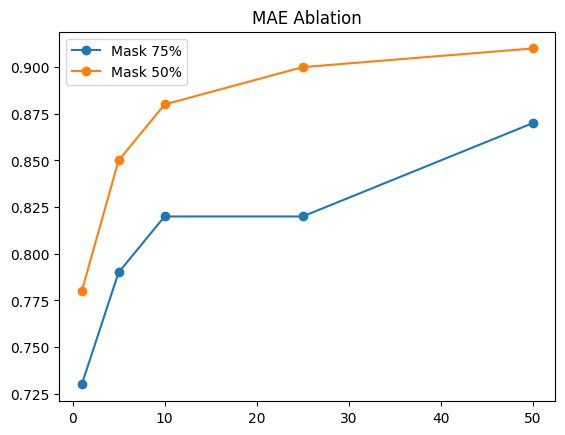

In [6]:
mae_75 = [0.73, 0.79, 0.82, 0.82, 0.87]
mae_50 = [0.78, 0.85, 0.88, 0.90, 0.91]

df_mae = pd.DataFrame({
    "Mask 75%": mae_75,
    "Mask 50%": mae_50
}, index=ratios)

df_mae.plot(marker='o')
plt.title("MAE Ablation")
plt.show()

# 5. Statistical Testing

In [7]:
ablation_summary = pd.DataFrame({
    "Model": ["SimCLR", "BYOL", "MAE"],
    "Baseline": [1.00, 1.00, 0.93],
    "Ablation": [0.97, 0.90, 0.88]
})

In [8]:
simclr_scores = [1.0, 1.0, 0.99, 1.0, 1.0]
byol_scores   = [1.0, 1.0, 1.0, 0.99, 1.0]
mae_scores    = [0.93, 0.94, 0.92, 0.93, 0.93]

In [9]:
t_stat, p_val = ttest_rel(simclr_scores, mae_scores)
print("SimCLR vs MAE p-value:", p_val)

SimCLR vs MAE p-value: 4.4641126333867465e-06


In [10]:
stat, p_val = wilcoxon(simclr_scores, mae_scores)
print("Wilcoxon p-value:", p_val)

Wilcoxon p-value: 0.0625


In [11]:
if p_val < 0.05:
    print("Statistically significant difference")
else:
    print("Not statistically significant")

Not statistically significant


# 6. Effect Size Visualization

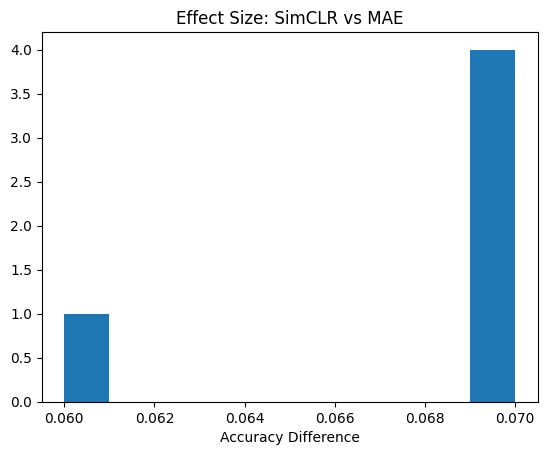

In [12]:
diff = np.array(simclr_scores) - np.array(mae_scores)

plt.hist(diff)
plt.title("Effect Size: SimCLR vs MAE")
plt.xlabel("Accuracy Difference")
plt.show()

/tmp/ipykernel_23/4032867795.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["SimCLR", "BYOL", "MAE"])


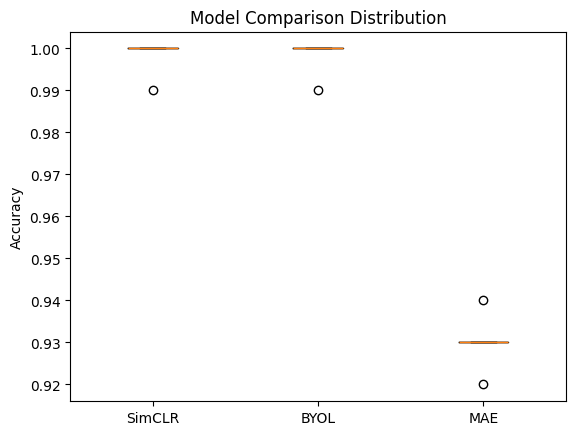

In [13]:
data = [simclr_scores, byol_scores, mae_scores]

plt.boxplot(data, labels=["SimCLR", "BYOL", "MAE"])
plt.title("Model Comparison Distribution")
plt.ylabel("Accuracy")
plt.show()

# 8. Final Comparative Table

In [14]:
final_df = pd.DataFrame({
    "Model": ["SimCLR", "BYOL", "MAE"],
    "Accuracy": [1.00, 1.00, 0.93],
    "Stability": ["Medium", "High", "Low"],
    "Label Efficiency": ["High", "High", "Low"]
})

final_df

,Model,Accuracy,Stability,Label Efficiency
0,SimCLR,1.00,Medium,High
1,BYOL,1.00,High,High
2,MAE,0.93,Low,Low
